# Bibliotecas

## Instalaciones

In [ ]:
!pip install -U spacy #-U para asegurar que se utiliza la biblioteca mas reciente, de update
!pip install -U gensim
!pip install wordcloud
!python -m spacy download en_core_web_lg


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 43.3 MB/s eta 0:00:00
  Attempting uninstall: spacy
    Found existing installation: spacy 3.8.8
    Uninstalling spacy-3.8.8:
      Successfully uninstalled spacy-3.8.8
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 1.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Importaciones

In [ ]:
#se reutilizan las bibliotecas de la practica de embeddings
import spacy
import gensim.downloader
import nltk
from nltk.corpus import stopwords
import re
import numpy as np
import pandas as pd
import joblib #para guardar los modelos, porque tardan mucho en entrenarse y ya baje n_iter a 10
#Bibliotecas para los modelos
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
#EDA
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.probability import FreqDist
from wordcloud import WordCloud

#import warnings
#warnings.filterwarnings('ignore')
nltk.download('stopwords')
def separador():
    print("\n" + "=" * 170 + "\n")
def header(Titulo):
  por=((170-len(Titulo))//10)
  a=int(1.2*por)
  print("."*a+"·"*a+"~"*a+"≈"*a+"≋"
  *int(por*.2),Titulo,"≋"*int(por*.2)
  +"≈"*a+"~"*a+"·"*a+"."*a,"\n\n")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Spacy y Gensim

In [ ]:
nlp = spacy.load("en_core_web_lg")
model_gensim = gensim.downloader.load('fasttext-wiki-news-subwords-300')
VECTOR_SIZE = model_gensim.vector_size
stop_words_en = set(stopwords.words('english'))
print('Carga exitosa')


[==================================================] 100.0% 958.5/958.4MB downloaded
Carga exitosa


# Funciones para Preprocesamiento

In [ ]:
def limpiar_y_lematizar(texto):
    doc = nlp(texto.lower())
    lemmas = [token.lemma_ for token in doc
              if not token.is_stop and
                 token.lemma_ not in stop_words_en and
                 token.is_alpha and
                 len(token.lemma_) > 1]
    return lemmas

def vectorizar_frase(frase_texto, modelo, nlp_spacy):
    lemmas_limpios = limpiar_y_lematizar(frase_texto)
    vectores_palabras = [modelo[palabra] for palabra in lemmas_limpios
                         if palabra in modelo.key_to_index]
    if len(vectores_palabras) > 0:
        return np.mean(vectores_palabras, axis=0)
    else:
        return np.zeros(VECTOR_SIZE)

print('Texto preprocesado')#para imprimir que ya esta lista la celda

Texto preprocesado


# EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6661 entries, 0 to 6660
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   phrase  6661 non-null   object
 1   prompt  6661 non-null   object
dtypes: object(2)
memory usage: 104.2+ KB
None



Número de clases únicas: 25




/tmp/ipython-input-1736883694.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='prompt', data=df, palette='mako', order=df['prompt'].value_counts().index)


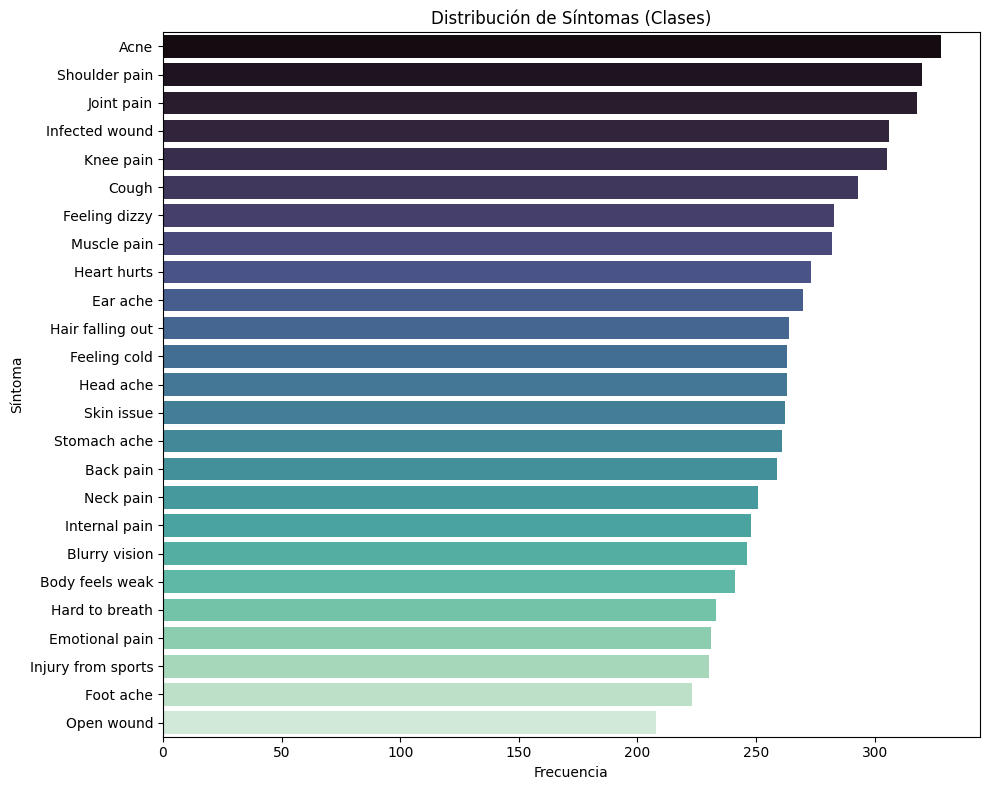

................················~~~~~~~~~~~~~~~~≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≋≋ Frecuencia y Wordcloud ≋≋≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈~~~~~~~~~~~~~~~~················................ 



25 Palabras más frecuentes:
[('feel', 1984), ('pain', 1634), ('hurt', 590), ('like', 507), ('ache', 383), ('knee', 358), ('shoulder', 340), ('head', 319), ('hair', 312), ('cold', 291), ('body', 275), ('neck', 272), ('ear', 272), ('skin', 257), ('foot', 257), ('stomach', 253), ('try', 253), ('stand', 238), ('heart', 236), ('lot', 231), ('walk', 230), ('time', 223), ('fall', 219), ('joint', 214), ('wound', 207)]


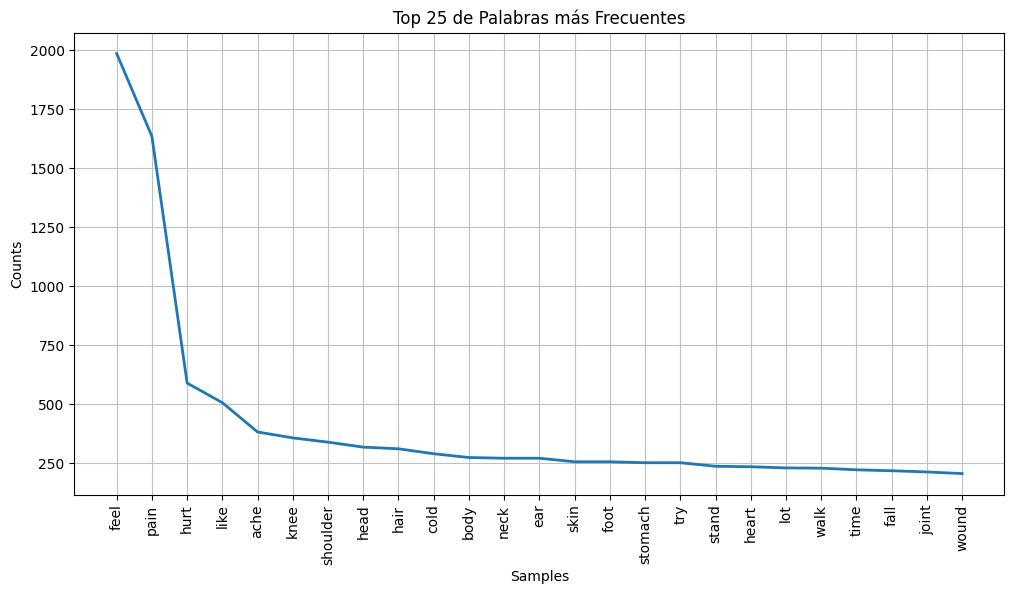

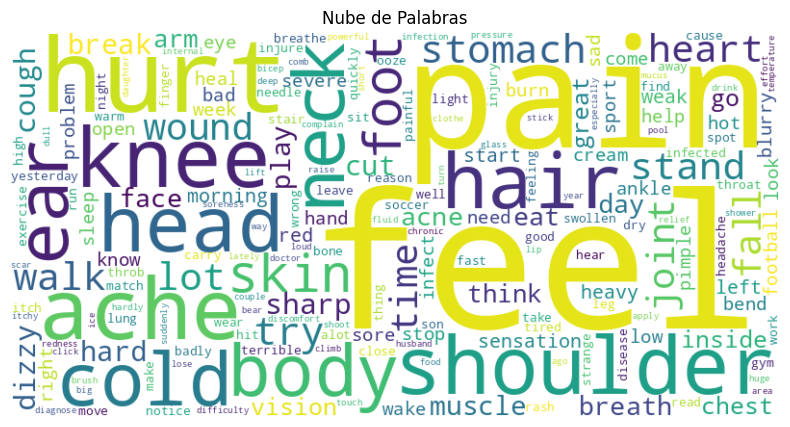

In [ ]:
#Se carga el archivo csv que se nos proporcionó del trabajo final
df = pd.read_csv("/content/drive/MyDrive/MAESTRIA/PLN/datos_final_pln.csv")


print(df.info())
separador()
print(f"\nNúmero de clases únicas: {df['prompt'].nunique()}")
separador()
plt.figure(figsize=(10, 8))
sns.countplot(y='prompt', data=df, palette='mako', order=df['prompt'].value_counts().index)
plt.title('Distribución de Síntomas (Clases)')
plt.xlabel('Frecuencia')
plt.ylabel('Síntoma')
plt.tight_layout()
plt.show()


#Frecuencia y wordcloud
header('Frecuencia y Wordcloud')
texto_completo_eda = df['phrase'].str.cat(sep=' ')
lemmas_para_eda = limpiar_y_lematizar(texto_completo_eda)

fdist = nltk.FreqDist(lemmas_para_eda)
print(f"\n25 Palabras más frecuentes:\n{fdist.most_common(25)}")


plt.figure(figsize=(12, 6))
fdist.plot(25, cumulative=False, title='Top 25 de Palabras más Frecuentes')
plt.show() ;separador()

texto_para_wordcloud = " ".join(lemmas_para_eda)
wordcloud = WordCloud(width=800, height=400, background_color='white',collocations=False).generate(texto_para_wordcloud)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Nube de Palabras')
plt.show()



# Pipelines

In [ ]:
#Vectorización del texto y definicion de X, y

df['vector'] = df['phrase'].apply(lambda text: vectorizar_frase(text, model_gensim, nlp))
X = np.array(df['vector'].tolist())
le = LabelEncoder()
y = le.fit_transform(df['prompt'])

print(f"Forma de X (vectores): {X.shape}")
print(f"Forma de y (etiquetas): {y.shape}")

#Hold out de 80% para entrenamiento con validación cruzada de 10 folds y 20% para el test al final
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=11,stratify=y)

#Configuración de hiperparametros, en las instrucciones se indica que se permite GridSearch, pero por rapidez utilizo RandomizedGridSearchCV
#Cada modelo va a seguido por los parametros que va a probar el grid

rs=11 #para que todos los random_State sean iguales, y los resultados replicables
cv_strat_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=rs)

#Regresión Logística
pipe_lr = Pipeline([('scaler', StandardScaler()),('model', LogisticRegression(random_state=rs))])
params_lr = {'model__C': np.logspace(-3, 2, 50),'model__penalty': ['l2']}

#Maquina de soporte vectorial (SVM)
pipe_svc = Pipeline([('scaler', StandardScaler()),('model', SVC(random_state=rs, probability=True))])
params_svc = {'model__C': np.logspace(-3, 2, 50),'model__gamma': np.logspace(-4, 1, 50),'model__kernel': ['rbf', 'poly']}

# Random Forest
pipe_rf = Pipeline([('model', RandomForestClassifier(random_state=rs))])
params_rf = {'model__n_estimators': [100, 200, 300, 400],'model__max_depth': [10, 20, 30, 40, None],'model__min_samples_leaf': [1, 2, 4],'model__min_samples_split': [2, 5, 10]}


n_iter_search = 10 #Para que no dure TANTO
scoring_metric = 'f1_weighted'

rs_lr = RandomizedSearchCV(pipe_lr, params_lr, n_iter=n_iter_search,cv=cv_strat_10, scoring=scoring_metric, n_jobs=-1, random_state=rs, verbose=1)
rs_svc = RandomizedSearchCV(pipe_svc, params_svc, n_iter=n_iter_search,cv=cv_strat_10, scoring=scoring_metric, n_jobs=-1, random_state=rs, verbose=1)
rs_rf = RandomizedSearchCV(pipe_rf, params_rf, n_iter=n_iter_search,cv=cv_strat_10, scoring=scoring_metric, n_jobs=-1, random_state=rs, verbose=1)

searches = [('Regresión Logística', rs_lr),('Support Vector Machine (SVC)', rs_svc),('Random Forest', rs_rf)]


Forma de X (vectores): (6661, 300)
Forma de y (etiquetas): (6661,)


# Entrenamiento

In [ ]:
header('Entrenamiento de modelos')
results_list = []
DRIVE_PATH = "/content/drive/MyDrive/MAESTRIA/PLN/"
# ------------------------------------------------

for nombre_modelo, search_obj in searches:
    print(f"\nEntrenando {nombre_modelo}...")
    search_obj.fit(X_train, y_train)
    print(f"Entrenamiento de {nombre_modelo} completado.")


    #Se guarda cada modelo, porque tarda mucho para entrenar
    model_filename = f'modelo_entrenado_{nombre_modelo.replace(" ", "_")}.joblib'
    full_save_path = DRIVE_PATH + model_filename
    joblib.dump(search_obj, full_save_path)
    print(f"Modelo guardado en: {full_save_path}")

    #Se suman los resultados a la lista "results_list"
    results_list.append({'Modelo': nombre_modelo,'Best Score (CV F1-Weighted)': search_obj.best_score_,'Best Params': search_obj.best_params_})


................················~~~~~~~~~~~~~~~~≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≋≋ Entrenamiento de modelos ≋≋≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈~~~~~~~~~~~~~~~~················................ 



Entrenando Regresión Logística...
Fitting 10 folds for each of 10 candidates, totalling 100 fits
Entrenamiento de Regresión Logística completado.
Modelo guardado en: /content/drive/MyDrive/MAESTRIA/PLN/modelo_entrenado_Regresión_Logística.joblib

Entrenando Support Vector Machine (SVC)...
Fitting 10 folds for each of 10 candidates, totalling 100 fits
Entrenamiento de Support Vector Machine (SVC) completado.
Modelo guardado en: /content/drive/MyDrive/MAESTRIA/PLN/modelo_entrenado_Support_Vector_Machine_(SVC).joblib

Entrenando Random Forest...
Fitting 10 folds for each of 10 candidates, totalling 100 fits
Entrenamiento de Random Forest completado.
Modelo guardado en: /content/drive/MyDrive/MAESTRIA/PLN/modelo_entrenado_Random_Forest.joblib


# Mejor Modelo

In [ ]:
header('Comparación de resultados')

results_df = pd.DataFrame(results_list).sort_values(by='Best Score (CV F1-Weighted)', ascending=False) #se convierten los resultados a un df por mejor organización
print(results_df.to_string())


mejor_modelo_nombre = results_df.iloc[0]['Modelo']
mejor_search_obj = [s[1] for s in searches if s[0] == mejor_modelo_nombre][0]

print(f"\n--- REPORTE FINAL DEL MEJOR MODELO ({mejor_modelo_nombre}) EN DATOS DE PRUEBA (TEST) ---")

y_pred_final = mejor_search_obj.predict(X_test)
print(classification_report(y_test, y_pred_final, target_names=le.classes_))
acc_final = accuracy_score(y_test, y_pred_final)
print(f"Accuracy final en Test: {acc_final:.4f}")


................················~~~~~~~~~~~~~~~~≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≋≋ Comparación de resultados ≋≋≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈≈~~~~~~~~~~~~~~~~················................ 


                         Modelo  Best Score (CV F1-Weighted)                                                                                                        Best Params
2                 Random Forest                     0.997176  {'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 10}
1  Support Vector Machine (SVC)                     0.997176                    {'model__kernel': 'poly', 'model__gamma': 0.01757510624854793, 'model__C': 0.08685113737513529}
0           Regresión Logística                     0.995094                                                           {'model__penalty': 'l2', 'model__C': 0.1757510624854793}

--- REPORTE FINAL DEL MEJOR MODELO (Random Forest) EN DATOS DE PRUEBA (TEST) ---
                    precision    recall  f1-score  